# Adaboost 

# Adaboost for Classification

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

In [3]:
print(data.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [4]:
print(data.target_names)

['malignant' 'benign']


In [5]:
print(X[:5,])

[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-02 3.832e-02 2.058e-02 2.250e-02 4.571e-03 2.357e+01
  2.553e+01 1.525e+02 1.709e+03 1.444e-01 4.245e-01 4.504e-01 2.430e-01
  3.613e-01 8.758e-02]
 [1.142e+01 2.038e+01 7.758e+01 3.861e+02 1.425e-01 2.839e-01 2.414

# 0 → Malignant  => Cancerous tumor => More dangerous.
# 1 → Benign => Non-cancerous tumor => Less dangerous

In [6]:
print(y[0:5])

[0 0 0 0 0]


In [7]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
# Weak learner
base_model = DecisionTreeClassifier(max_depth=1)

In [9]:
# AdaBoost classifier
ada_clf = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

# Train
ada_clf.fit(X_train, y_train)

# Prediction
y_pred = ada_clf.predict(X_test)

In [10]:
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9736842105263158


In [11]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [12]:
print(ada_clf.feature_importances_)

[0.   0.07 0.   0.01 0.05 0.05 0.03 0.04 0.04 0.02 0.02 0.   0.01 0.05
 0.02 0.07 0.   0.04 0.02 0.03 0.01 0.07 0.03 0.07 0.06 0.   0.04 0.05
 0.09 0.01]


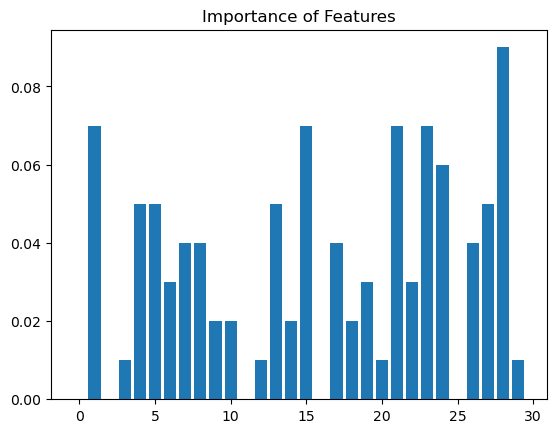

In [13]:
import matplotlib.pyplot as plt

importance = ada_clf.feature_importances_

plt.bar(range(len(importance)), importance)
plt.title("Importance of Features")
plt.show()

# Adaboost for Regression

In [14]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [15]:
# Load dataset
data = fetch_california_housing()

X = data.data
y = data.target

In [16]:
print(data.feature_names)
print(data.target_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
['MedHouseVal']


In [17]:
print(X[0:5,])

[[ 8.32520000e+00  4.10000000e+01  6.98412698e+00  1.02380952e+00
   3.22000000e+02  2.55555556e+00  3.78800000e+01 -1.22230000e+02]
 [ 8.30140000e+00  2.10000000e+01  6.23813708e+00  9.71880492e-01
   2.40100000e+03  2.10984183e+00  3.78600000e+01 -1.22220000e+02]
 [ 7.25740000e+00  5.20000000e+01  8.28813559e+00  1.07344633e+00
   4.96000000e+02  2.80225989e+00  3.78500000e+01 -1.22240000e+02]
 [ 5.64310000e+00  5.20000000e+01  5.81735160e+00  1.07305936e+00
   5.58000000e+02  2.54794521e+00  3.78500000e+01 -1.22250000e+02]
 [ 3.84620000e+00  5.20000000e+01  6.28185328e+00  1.08108108e+00
   5.65000000e+02  2.18146718e+00  3.78500000e+01 -1.22250000e+02]]


In [18]:
print(y[0:5])

[4.526 3.585 3.521 3.413 3.422]


In [19]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
# Weak learner
base_model = DecisionTreeRegressor(max_depth=4)

# AdaBoost regressor
ada_reg = AdaBoostRegressor(
    estimator=base_model,
    n_estimators=100,
    learning_rate=0.5,
    loss='linear',
    random_state=42
)

In [21]:
# Train model
ada_reg.fit(X_train, y_train)

# Predictions
y_pred = ada_reg.predict(X_test)

print(y_pred)

[1.39358814 1.89257406 3.29407845 ... 3.84758637 1.54207267 2.73485882]


In [22]:
# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))

print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.7483253382392666
R2 Score: 0.4377867008683213


In [23]:
print(ada_reg.feature_importances_)

[0.28387414 0.04667898 0.06454222 0.03749498 0.06272682 0.12304201
 0.17740046 0.20424039]


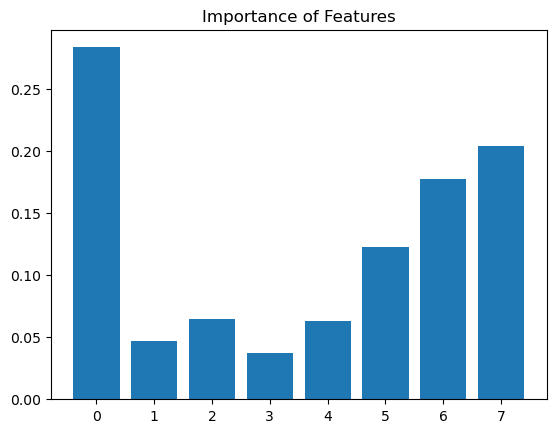

In [24]:
import matplotlib.pyplot as plt

importance = ada_reg.feature_importances_

plt.bar(range(len(importance)), importance)
plt.title("Importance of Features")
plt.show()